In [1]:
import sys
sys.path.append("..")

In [2]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path ="sms_spam_collection.zip"
extracted_path ="sms_spam_collection"
data_file_path= Path(extracted_path)/ "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
   if data_file_path.exists():
       print(f"{data_file_path} already exists. Skipping download "
        "and extraction."
    )
       return

   with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
   with zipfile.ZipFile(zip_path, "r") as zip_ref:  
       zip_ref.extractall(extracted_path)

   original_file_path= Path(extracted_path)/ "SMSSpamCollection"
   os.rename(original_file_path, data_file_path)
   print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url,zip_path, extracted_path,data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [3]:
import pandas as pd
df= pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "text"])
df

,Label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
# balanced dataset
def create_balanced_dataset(df):
    num_spam =df[df["Label"]== "spam"].shape[0] #instances of spam
    ham_subset =df[df["Label"]== "ham"].sample(num_spam, random_state=123)
    balanced_df =pd.concat([ham_subset, df[df["Label"]== "spam"]])
    return balanced_df

balanced_df =create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [6]:
# convertin string class labels to integer class labels
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [7]:
# splitting
def random_split(df, train_frac, validation_frac):
    df =df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac) 
    validation_end = train_end + int(len(df) * validation_frac)
    train_df= df[:train_end]
    validation_df =df[train_end: validation_end]
    test_df =df[validation_end: ]

    return train_df, validation_df, test_df

train_df, validation_df, test_df=random_split(balanced_df, 0.7,0.1)

In [8]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [10]:
# dataset class
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file,tokenizer, max_length=None, pad_tokenid=50256):
        self.data =pd.read_csv(csv_file)
        self.encoded_texts =[tokenizer.encode(text) for text in self.data["text"]]  #pretokenizes text

        if max_length is None:
            self.max_length =self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts= [encoded_text[:self.max_length]  for encoded_text in self.encoded_texts]

        self.encoded_texts =[encoded_text +[pad_tokenid]*(self.max_length -len(encoded_text)) for encoded_text in self.encoded_texts]

    def __getitem__(self, index):
        encoded =self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long))
    def __len__(self):
        return len(self.data)
    def _longest_encoded_length(self):
        max_length =0
        for encoded_text in self.encoded_texts:
            encoded_length =len(encoded_text)
            if encoded_length >max_length:
                max_length =encoded_length
        return max_length

In [11]:
train_dataset =SpamDataset(csv_file="train.csv", max_length=None, tokenizer=tokenizer)
print(train_dataset.max_length)

120


In [12]:
val_dataset =SpamDataset(csv_file="validation.csv", max_length=None, tokenizer=tokenizer)
test_dataset =SpamDataset(csv_file="test.csv", max_length=None, tokenizer=tokenizer)

In [13]:
# data loaders
from torch.utils.data import DataLoader

num_workers =0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)

In [14]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [15]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [16]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
"vocab_size": 50257,
"context_length": 1024,
"drop_rate": 0.0,
"qkv_bias": True
} 

model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [17]:
from utils.load_weight_gpt import load_weights_ingpt
from pretraining.gpt_download import download_and_load_gpt2 
from components.model import GPTModel

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
model_size=model_size, models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_ingpt(model, params)
print("BEFORE:")
print(model.out_head.weight[0, :5])

model.out_head.weight = torch.nn.Parameter(
    torch.tensor(params["wte"], dtype=model.out_head.weight.dtype)
)

print("AFTER:")
print(model.out_head.weight[0, :5])

print(
    "OUT == TOKEN:",
    torch.allclose(model.out_head.weight, model.tok_emb.weight)
)
model.eval() 

torch version 2.12.1
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
tensor([0.4419, 0.6515, 0.5683])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [18]:
print("Embedding weight:")
print(model.tok_emb.weight[0, :10])

print("\nGPT-2 checkpoint:")
print(torch.tensor(params["wte"])[0, :10])

print(
    torch.allclose(
        model.tok_emb.weight,
        torch.tensor(params["wte"])
    )
)
print(
    torch.allclose(
        model.out_head.weight,
        torch.tensor(params["wte"])
    )
)
# import tiktoken
# import torch

# tokenizer = tiktoken.get_encoding("gpt2")

# text = "Every effort moves you"

# idx = torch.tensor(
#     tokenizer.encode(text),
#     dtype=torch.long
# ).unsqueeze(0)

# print("Input:", idx.shape)

# with torch.no_grad():
#     logits = model(idx)

# print("Logits:", logits.shape)

# next_token = logits[:, -1, :].argmax(dim=-1)

# print("Next token ID:", next_token.item())
# print("Next token:", tokenizer.decode(next_token.tolist()))

Embedding weight:
tensor([-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
         0.0253, -0.1074], grad_fn=<SliceBackward0>)

GPT-2 checkpoint:
tensor([-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
         0.0253, -0.1074])
True
True


In [19]:
print(model.out_head.weight.shape)
print(torch.tensor(params["wte"]).shape)

print(model.out_head.weight[:2, :10])
print(torch.tensor(params["wte"])[:2, :10])
print(torch.allclose(
    model.out_head.weight,
    model.tok_emb.weight
))

torch.Size([50257, 768])
torch.Size([50257, 768])
tensor([[-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
          0.0253, -0.1074],
        [ 0.0403, -0.0486,  0.0462, -0.0990,  0.0826,  0.0768, -0.2202, -0.0110,
          0.0592,  0.0354]], grad_fn=<SliceBackward0>)
tensor([[-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
          0.0253, -0.1074],
        [ 0.0403, -0.0486,  0.0462, -0.0990,  0.0826,  0.0768, -0.2202, -0.0110,
          0.0592,  0.0354]])


True


In [20]:
from components.model import generate_text_simple
from components.pretrain import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
model=model,
idx=text_to_token_ids(text_1, tokenizer),
max_new_tokens=15,
context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))


Every effort moves you forward.

The first step is to understand the importance of your work


In [21]:
text_2 = (
"Is the following text 'spam'? Answer with 'yes' or 'no':"
" 'You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
model=model,
idx=text_to_token_ids(text_2, tokenizer),
max_new_tokens=23,
context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [22]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [23]:
# freezin the model
for param in model.parameters():
    param.requires_grad =False

In [24]:
# addin classification layer
torch.manual_seed(123)
num_classes =2
model.out_head= torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

In [25]:
# making layernorm and last transformer block trainable
for param in model.trf_blocks[-1].parameters():
    param.requires_grad =True
for param in model.final_norm.parameters():
    param.requires_grad =True

In [26]:
inputs =tokenizer.encode("Do you have time")
inputs =torch.tensor(inputs).unsqueeze(0)
print("Inputs: ", inputs)
print("Inputs dimension: ", inputs.shape)

Inputs:  tensor([[5211,  345,  423,  640]])
Inputs dimension:  torch.Size([1, 4])


In [27]:
# passing encoded token ids to model
with torch.no_grad():
    outputs =model(inputs)
print("Outputs: \n", outputs)
print("Outputs dimension: \n", outputs.shape) 

# extractin last output token from tensor
print("Last output token: ", outputs[: ,-1:])

Outputs: 
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimension: 
 torch.Size([1, 4, 2])
Last output token:  tensor([[[-3.5983,  3.9902]]])


In [28]:
probas = torch.softmax(outputs[:,-1,:], dim=-1)
label =torch.argmax(probas)
print("Class label : ", label.item())

Class label :  1


In [29]:
logits =outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [30]:
# classification accuracy
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples =0, 0

    if num_batches is None:
        num_batches =len(data_loader)
    else :
        num_batches =min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i <num_batches:
            input_batch =input_batch.to(device)
            target_batch = target_batch.to(device)
            with torch.no_grad():
                logits =model(input_batch)[:, -1,:]
            predicted_labels =torch.argmax(logits, dim= -1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += ((predicted_labels ==target_batch).sum().item())
        else:
            break
    return correct_predictions/num_examples

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 53.75%
Test accuracy: 50.00%


In [32]:
def calc_loss_batch(input_batch,target_batch,model, device):
    input_batch =input_batch.to(device)
    target_batch =target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss =torch.nn.functional.cross_entropy(logits,target_batch)
    return loss

# classification loss
def calc_loss_loader(data_loader,model, device, num_batches=None):
    total_loss = 0
    if len(data_loader)== 0:
        return float("nan")
    elif num_batches is None:
        num_batches =len(data_loader)
    else:
        num_batches =min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [33]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 3.211
Validation loss: 2.388
Test loss: 2.538


In [34]:
# finetuning to classify span
def train_classifier_simple(model, train_loader,val_loader, optimizer,device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs =[],[],[],[]
    examples_seen,global_step = 0,-1

    for epoch in range(num_epochs):
        model.train()   #setting to training mode

        for input_batch,target_batch in train_loader:
            optimizer.zero_grad()
            loss =calc_loss_batch(input_batch, target_batch,model, device)
            loss.backward()
            optimizer.step()    #updates model weights using loss gradients
            examples_seen +=input_batch.shape[0]
            global_step +=1

            if global_step%eval_freq == 0:
                train_loss, val_loss =evaluate_model(model, train_loader, val_loader, device,eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                f"Train loss {train_loss:.3f}, "
                f"Val loss {val_loss:.3f}"
                )

        train_accuracy =calc_accuracy_loader(train_loader, model,device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model,device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses,train_accs, val_accs, examples_seen
    
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss =calc_loss_loader(train_loader, model,device, num_batches=eval_iter)
        val_loss =calc_loss_loader(val_loader,  model,device, num_batches=eval_iter)
    model.train()
    return train_loss,val_loss

In [35]:
# testing it out
import time

start_time =time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs =5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time =time.time()
execution_time_minutes= (end_time -start_time)/ 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.808
Ep 1 (Step 000050): Train loss 0.631, Val loss 0.566
Ep 1 (Step 000100): Train loss 0.498, Val loss 0.617
Training accuracy: 75.00% | Validation accuracy: 85.00%
Ep 2 (Step 000150): Train loss 0.494, Val loss 0.527
Ep 2 (Step 000200): Train loss 0.363, Val loss 0.750
Ep 2 (Step 000250): Train loss 0.455, Val loss 0.459
Training accuracy: 70.00% | Validation accuracy: 77.50%
Ep 3 (Step 000300): Train loss 0.414, Val loss 0.567
Ep 3 (Step 000350): Train loss 0.485, Val loss 0.338
Training accuracy: 87.50% | Validation accuracy: 87.50%
Ep 4 (Step 000400): Train loss 0.220, Val loss 0.387
Ep 4 (Step 000450): Train loss 0.204, Val loss 0.489
Ep 4 (Step 000500): Train loss 0.147, Val loss 0.203
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.123, Val loss 0.120
Ep 5 (Step 000600): Train loss 0.054, Val loss 0.268
Training accuracy: 95.00% | Validation accuracy: 92.50%
Training completed in 42.53 min

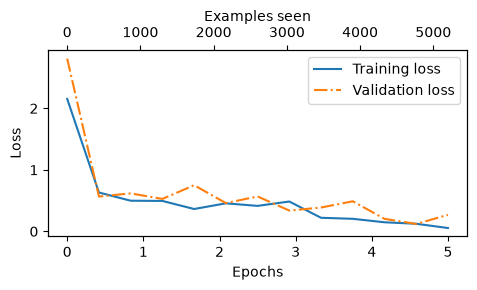

In [36]:
import matplotlib.pyplot as plt
def plot_values(
    epochs_seen, examples_seen, train_values, val_values,
    label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
    epochs_seen, val_values, linestyle="-.",
    label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor,examples_seen_tensor,train_losses, val_losses)

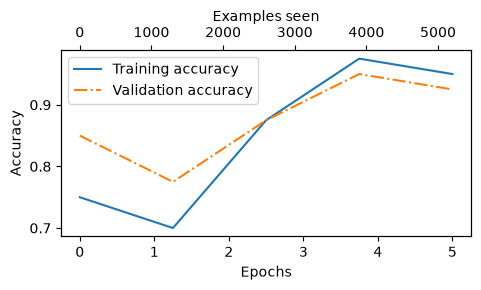

In [37]:
# classification accuracies
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs,label="accuracy")

In [38]:
# classifying new texts
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # prepares inputs to model
    input_ids =tokenizer.encode(text)
    supported_context_length =model.pos_emb.weight.shape[1]
    # trncates sequences if they are too long
    input_ids =input_ids[:min(max_length,supported_context_length)]
    input_ids +=[pad_token_id]*(max_length -len(input_ids)) 
    input_tensor =torch.tensor(input_ids, device=device).unsqueeze(0)

    with torch.no_grad():
        logits =model(input_tensor)[:, -1, :]
    predicted_label =torch.argmax(logits, dim=-1)

    return "spam" if predicted_label ==1 else "not spam"

In [ ]:
text_1 = (
"You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award."
)
print(classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))

spam


In [40]:
text_2 = (
"Hey, just wanted to check if we're still on"
" for dinner tonight? Let me know!"
)

print(classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length))

not spam


In [49]:
torch.save(model.state_dict(), "review_classifier.pth")

In [ ]:
model_state_dict = torch.load("review_classifier.pth, map_location=device")
model.load_state_dict(model_state_dict)